# 1.1 Exploración de datos

**Actividad 1.1**
- Explica qué representa cada fila de la base y qué columnas la identifican.
- Indica cómo separarías la información en tablas o catálogos.
- Revisa si la base y los catálogos entregados coinciden entre sí.

**Contenido**
- **1.1.a** ¿Qué representa cada fila y qué columnas la identifican?
- **1.1.b** ¿Cómo separar la información en tablas?
- **1.1.c** ¿El dataset y los catálogos coinciden? (vista general; el detalle está en `1_2_validacion_catalogos`)

| Artefacto | Ruta |
|---|---|
| Entrada | `0_datos/KPIS_historico.xlsx` |


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 80)

ARCHIVO = Path("../../0_datos/KPIS_historico.xlsx")
VERDE, AMARILLO, NARANJA, ROJO, AZUL, MORADO, ROSADO, GRIS = (
    "#00c389", "#fdda24", "#ff7f41", "#e03c31", "#59cbe8", "#9063cd", "#f5b6cd", "#9e9a99")

kpis = pd.read_excel(ARCHIVO, sheet_name="query", dtype={"Corte": str, "Codigo_EQU": str, "EQU": str})
cat_indicadores = pd.read_excel(ARCHIVO, sheet_name="catalogo_indicadores", dtype=str)
cat_entornos = pd.read_excel(ARCHIVO, sheet_name="catalogo_entornos", dtype=str)

# Un mismo equipo aparece escrito de varias formas (Equ00074 / EQU00074, EQU0024 / EQU00024): se unifica para contar equipos
kpis["codigo_equipo"] = kpis["Codigo_EQU"].str.upper().str.replace(r"^([A-Z]{3})0(\d{3})$", r"\g<1>00\2", regex=True)


def simplificar(texto):
    """Minúsculas y sin tildes, para detectar nombres que solo difieren en la escritura."""
    return texto.lower().replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")


def limpiar_ejes(ax, lados=("top", "right")):
    ax.spines[list(lados)].set_visible(False)


print("Hojas cargadas:")
for nombre, hoja in [("query", kpis), ("catalogo_indicadores", cat_indicadores), ("catalogo_entornos", cat_entornos)]:
    print(f"  {nombre:<22} {len(hoja):>6} filas")


Hojas cargadas:
  query                   15188 filas
  catalogo_indicadores       13 filas
  catalogo_entornos          64 filas


## 1.1.a ¿Qué representa cada fila y qué columnas la identifican?

Una fila de `query` es **el resultado de un indicador, para un equipo, en un mes**: el equipo `Codigo_EQU` obtuvo `Resultado` frente a una `Meta` en el `Corte` (mes AAAAMM), y eso equivale a un `Cumplimiento`.


In [2]:
print("Muestra de los KPIs:")
display(kpis.drop(columns="codigo_equipo").sample(3, random_state=7))

llave = ["Corte", "Codigo_EQU", "Indicador"]
filas_unicas = kpis.drop(columns="codigo_equipo").drop_duplicates()
print("Resumen de la información:")
print("  Filas totales:", len(kpis))
print("  Meses:", kpis["Corte"].nunique(), f"({kpis['Corte'].min()} a {kpis['Corte'].max()})")
print("  Filas repetidas exactamente igual:", len(kpis) - len(filas_unicas))
print("  Combinaciones distintas de mes, equipo e indicador:", filas_unicas[llave].drop_duplicates().shape[0])
print("  ¿El frente cambia para un mismo mes, equipo e indicador?:", filas_unicas.groupby(llave)["Frente"].nunique().max() > 1)


Muestra de los KPIs:


,Frente,Corte,Codigo_EQU,EQU,Indicador,Resultado,Meta,Cumplimiento
13003,Experiencia,202603,EQU00061,Equipo 61,ICX,4.390000,4.0,1.097500
8327,Modelos de trabajo y Agilidad,202502,EQU00072,NaN,Percepción,3.611111,5.0,3.611111
10566,TI,202506,EQU00044,NaN,Apps modernizadas,1.000000,1.0,1.000000


Resumen de la información:
  Filas totales: 15188
  Meses: 44 (202301 a 202608)
  Filas repetidas exactamente igual: 2182
  Combinaciones distintas de mes, equipo e indicador: 11961
  ¿El frente cambia para un mismo mes, equipo e indicador?: False


**Respuesta:** las columnas que identifican una fila son **`Corte` + `Codigo_EQU` + `Indicador`**. `Frente` depende del indicador y `EQU` (nombre) depende del código del equipo, por eso no hacen parte de la llave.
La llave casi se cumple: hay filas repetidas y algunos casos con más de un valor para la misma combinación (se cuantifican en `1_3_evaluacion_calidad`).

## 1.1.b ¿Cómo separar la información en tablas?

Hoy el Excel repite en cada fila el nombre del equipo y el frente. Separado en tablas quedaría así:


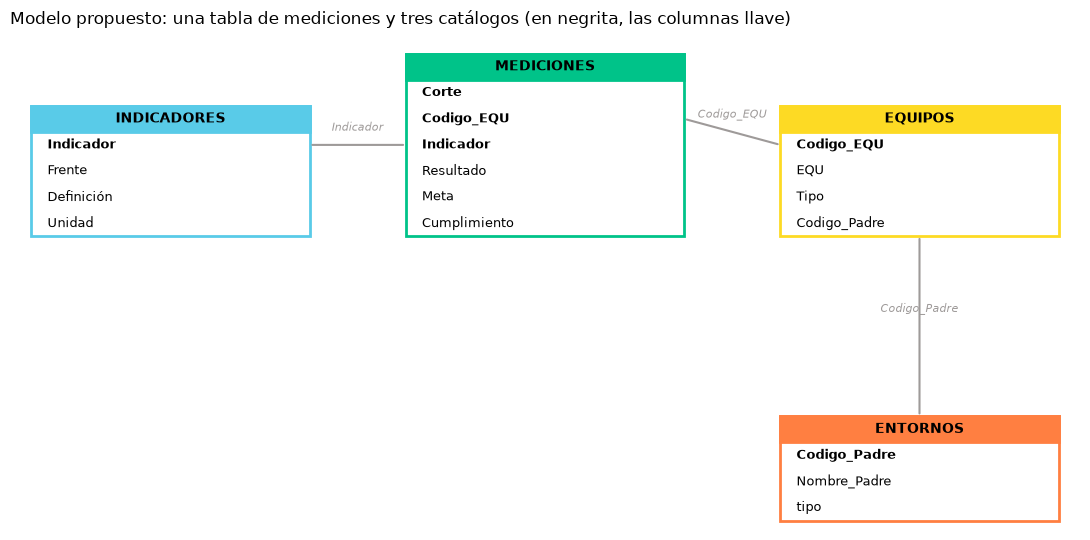

In [3]:
# Diagrama de tablas: cada caja es una tabla y cada línea la columna que las une (llave en negrita)
TABLAS = {  # nombre: (x, y, color, columnas)
    "INDICADORES": (0.02, 0.62, AZUL, ["Indicador", "Frente", "Definición", "Unidad"]),
    "MEDICIONES": (0.37, 0.62, VERDE, ["Corte", "Codigo_EQU", "Indicador", "Resultado", "Meta", "Cumplimiento"]),
    "EQUIPOS": (0.72, 0.62, AMARILLO, ["Codigo_EQU", "EQU", "Tipo", "Codigo_Padre"]),
    "ENTORNOS": (0.72, 0.02, NARANJA, ["Codigo_Padre", "Nombre_Padre", "tipo"]),
}
LLAVES = {"MEDICIONES": ["Corte", "Codigo_EQU", "Indicador"], "INDICADORES": ["Indicador"],
          "EQUIPOS": ["Codigo_EQU"], "ENTORNOS": ["Codigo_Padre"]}
ANCHO, ALTO_FILA = 0.26, 0.055

fig, ax = plt.subplots(figsize=(11, 5.5))
for nombre, (x, y, color, columnas) in TABLAS.items():
    alto = ALTO_FILA * (len(columnas) + 1)
    ax.add_patch(plt.Rectangle((x, y), ANCHO, alto, facecolor="white", edgecolor=color, lw=2))
    ax.add_patch(plt.Rectangle((x, y + alto - ALTO_FILA), ANCHO, ALTO_FILA, facecolor=color, edgecolor=color, lw=2))
    ax.text(x + ANCHO / 2, y + alto - ALTO_FILA / 2, nombre, ha="center", va="center", fontweight="bold", fontsize=10)
    for k, col in enumerate(columnas):
        es_llave = col in LLAVES[nombre]
        ax.text(x + 0.015, y + alto - ALTO_FILA * (k + 1.5), col, va="center", fontsize=9,
                fontweight="bold" if es_llave else "normal")

def unir(x1, y1, x2, y2, etiqueta):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="-", color=GRIS, lw=1.5))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.03, etiqueta, ha="center", fontsize=8, color=GRIS, style="italic")

def fila(tabla, columna):
    """Altura del centro de la fila de una columna dentro de su caja."""
    x, y, _, columnas = TABLAS[tabla]
    return y + ALTO_FILA * (len(columnas) + 1) - ALTO_FILA * (columnas.index(columna) + 1.5)

unir(0.37, fila("MEDICIONES", "Indicador"), 0.28, fila("INDICADORES", "Indicador"), "Indicador")
unir(0.63, fila("MEDICIONES", "Codigo_EQU"), 0.72, fila("EQUIPOS", "Codigo_EQU"), "Codigo_EQU")
unir(0.85, 0.62, 0.85, 0.02 + ALTO_FILA * 4, "Codigo_Padre")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.axis("off")
ax.set_title("Modelo propuesto: una tabla de mediciones y tres catálogos (en negrita, las columnas llave)", loc="left")
plt.tight_layout()
plt.show()


| Tabla | Una fila por | Viene de |
|---|---|---|
| **Mediciones** | mes × equipo × indicador | hoja `query` |
| **Equipos** | equipo | `catalogo_entornos` + nombres de `query` |
| **Entornos** | entorno o vicepresidencia | `catalogo_entornos` |
| **Indicadores** | indicador | `catalogo_indicadores` (+ los que faltan) |

Para que este modelo funcione, cada medición debe encontrar su indicador y su equipo en los catálogos.

## 1.1.c ¿El dataset y los catálogos coinciden?

La coincidencia se mide **una sola vez y en ambos sentidos**: se juntan todos los indicadores (o equipos) que aparecen en cualquiera de las dos hojas y se clasifica cada uno según dónde está.

| Grupo | Significa |
|---|---|
| En ambos | está en el dataset y en el catálogo con el mismo nombre |
| Escrito distinto | está en ambos, pero el nombre cambia (por ejemplo, una tilde) |
| Solo en el dataset | se mide, pero el catálogo no lo conoce |
| Solo en el catálogo | está documentado, pero nadie lo mide |


,En ambos,Escrito distinto,Solo en el dataset,Solo en el catálogo,Total distintos
Indicadores,10,1,14,2,27
Equipos,63,0,26,1,90


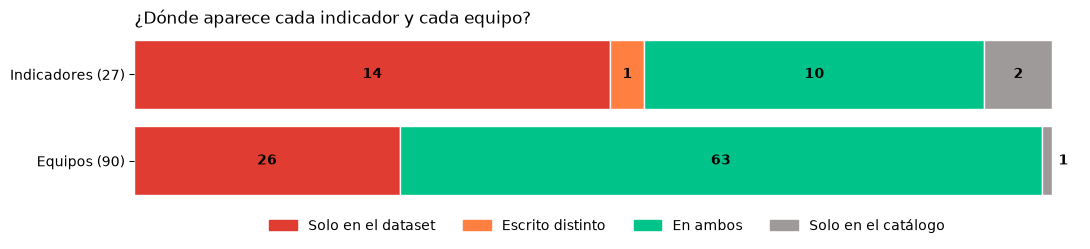

In [4]:
def clasificar(dataset, catalogo, normalizar=None):
    """Cuenta los elementos de ambas hojas según dónde aparecen."""
    ambos = dataset & catalogo
    distinto = set()
    if normalizar:
        dataset_norm = {normalizar(x): x for x in dataset - ambos}
        catalogo_norm = {normalizar(x): x for x in catalogo - ambos}
        distinto = {dataset_norm[n] for n in dataset_norm.keys() & catalogo_norm.keys()}
        catalogo = catalogo - {catalogo_norm[n] for n in dataset_norm.keys() & catalogo_norm.keys()}
    return {"En ambos": len(ambos), "Escrito distinto": len(distinto),
            "Solo en el dataset": len(dataset - ambos - distinto), "Solo en el catálogo": len(catalogo - ambos)}


coincidencia = pd.DataFrame({
    "Indicadores": clasificar(set(kpis["Indicador"]), set(cat_indicadores["Indicador"]), simplificar),
    "Equipos": clasificar(set(kpis["codigo_equipo"].dropna()), set(cat_entornos["Codigo_EQU"])),
}).T
coincidencia["Total distintos"] = coincidencia.sum(axis=1)
display(coincidencia)

colores = {"Solo en el dataset": ROJO, "Escrito distinto": NARANJA, "En ambos": VERDE, "Solo en el catálogo": GRIS}
fig, ax = plt.subplots(figsize=(11, 2.6))
for j, entidad in enumerate(["Equipos", "Indicadores"]):
    total, inicio = coincidencia.loc[entidad, "Total distintos"], 0
    for grupo, color in colores.items():
        ancho = coincidencia.loc[entidad, grupo] / total
        if ancho == 0:
            continue
        ax.barh(j, ancho, left=inicio, color=color, edgecolor="white")
        x_texto = inicio + ancho / 2 if ancho > 0.03 else inicio + ancho + 0.012  # segmentos angostos: número afuera
        ax.text(x_texto, j, str(coincidencia.loc[entidad, grupo]), ha="center", va="center", fontsize=10, fontweight="bold")
        inicio += ancho
ax.set_yticks([0, 1], [f"Equipos ({coincidencia.loc['Equipos', 'Total distintos']})",
                       f"Indicadores ({coincidencia.loc['Indicadores', 'Total distintos']})"])
ax.set_xticks([])
ax.set_xlim(0, 1.03)
ax.legend(handles=[Patch(color=c, label=g) for g, c in colores.items()], frameon=False, ncol=4,
          loc="upper center", bbox_to_anchor=(0.5, -0.02))
ax.set_title("¿Dónde aparece cada indicador y cada equipo?", loc="left")
limpiar_ejes(ax, ("top", "right", "bottom", "left"))
plt.tight_layout()
plt.show()


**Respuesta:** **no coinciden completamente**, y el desajuste está del lado del dataset.
- **Indicadores:** de 27 indicadores distintos entre las dos hojas, solo **10 coinciden** exactamente y 1 difiere por una tilde. **14 se miden sin estar en el catálogo** (más de la mitad de las filas) y **2 están en el catálogo pero nadie los mide**.
- **Equipos:** de 90 equipos distintos, **63 están en ambas hojas**, **26 solo aparecen en el dataset** (equipos fantasma) y 1 está en el catálogo sin mediciones.

El detalle de cada diferencia (qué indicadores, qué equipos y por qué) está en `1_2_validacion_catalogos`.
